# Лабораторная работа 1: Метод обратного распространения ошибки

## Постановка задачи

Обучить двухслойную полносвязную нейронную сеть для классификации рукописных цифр из датасета MNIST.

- **Входной слой**: 784 нейрона (28×28);
- **Скрытый слой**: $s$ нейронов, активация ReLU;
- **Выходной слой**: 10 нейронов, softmax.

Контрольные параметры:
- Размер пачки: 8–64 (здесь 32);
- Скорость обучения: 0.1;
- Скрытых нейронов $s$: 300;
- Эпох: 20.

Требуется достичь точности на тесте лучше 95% (ожидается при корректной инициализации весов).

## Теоретические основы метода обратного распространения ошибки

Нейронная сеть задаётся функцией от входа и параметров (весов). Обучение — минимизация функции потерь $L$ по параметрам.

### Архитектура

Двухслойная полносвязная сеть:

$$x \xrightarrow[FC]{W^{(x)}, b^{(x)}} z_1 \xrightarrow[ReLU]{} a_1 \xrightarrow[FC]{W^{(z)}, b^{(z)}} z_2 \xrightarrow[Softmax]{} a_2$$

- $x \in \mathbb{R}^{784}$ — вход (изображение 28×28, выпрямленное);
- $z_1, a_1$ — линейная комбинация и активации скрытого слоя;
- $z_2, a_2$ — линейная комбинация и вероятности классов.

**Прямой проход:**
$$z_1 = W^{(x)} x + b^{(x)}, \quad a_1 = \text{ReLU}(z_1)$$
$$z_2 = W^{(z)} a_1 + b^{(z)}, \quad a_2 = \text{Softmax}(z_2)$$
$$\text{ReLU}(t) = \max(0,t), \quad \text{Softmax}(v_j) = \frac{e^{v_j}}{\sum_i e^{v_i}}$$

### Функция потерь

Кросс-энтропия для многоклассовой классификации:
$$L = -\frac{1}{N}\sum_{k=1}^{N}\sum_{j=1}^{10} y_j^{(k)} \ln a_{2j}^{(k)}$$

($y$ — one-hot метка, $a_2$ — предсказанные вероятности.)

### Обратное распространение

Градиент на выходе (softmax + cross-entropy): $\delta^{(2)} = a_2 - y$.

Градиенты по весам и смещениям выходного слоя:
$$\frac{\partial L}{\partial W^{(z)}} = a_1^T \delta^{(2)}, \quad \frac{\partial L}{\partial b^{(z)}} = \sum \delta^{(2)}$$

Ошибка в скрытый слой и градиенты:
$$\delta^{(1)} = (\delta^{(2)} W^{(z)T}) \odot \text{ReLU}'(z_1)$$
$$\frac{\partial L}{\partial W^{(x)}} = x^T \delta^{(1)}, \quad \frac{\partial L}{\partial b^{(x)}} = \sum \delta^{(1)}$$

Обновление (SGD): $W \leftarrow W - \eta \frac{\partial L}{\partial W}$, $b \leftarrow b - \eta \frac{\partial L}{\partial b}$.

## Реализация

### Импорт библиотек и загрузка данных

In [1]:
%pip install idx2numpy kagglehub -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import idx2numpy
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Путь к датасету MNIST:", path)

x_train_raw = idx2numpy.convert_from_file(f"{path}/train-images.idx3-ubyte")
y_train = idx2numpy.convert_from_file(f"{path}/train-labels.idx1-ubyte")
x_test_raw = idx2numpy.convert_from_file(f"{path}/t10k-images.idx3-ubyte")
y_test = idx2numpy.convert_from_file(f"{path}/t10k-labels.idx1-ubyte")

print("Форма x_train:", x_train_raw.shape)
print("Форма y_train:", y_train.shape)
print("Форма x_test:", x_test_raw.shape)
print("Форма y_test:", y_test.shape)

100%|████████████████████████████████████████| 22.0M/22.0M [00:04<00:00, 5.33MB/s]

Extracting files...


Путь к датасету MNIST: C:\Users\retyr\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1
Форма x_train: (60000, 28, 28)
Форма y_train: (60000,)
Форма x_test: (10000, 28, 28)
Форма y_test: (10000,)


### Демонстрация изображений и меток

Проверка корректности загрузки и соответствия размерностей.

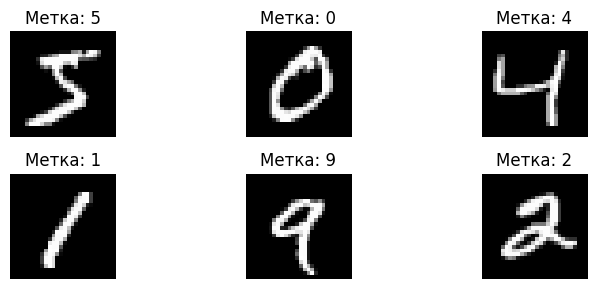

In [3]:
plt.figure(figsize=(8, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Метка: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Предобработка данных

- Выпрямление изображений 28×28 в вектор длины 784.
- Нормализация пикселей в диапазон [0, 1] (деление на 255).

In [4]:
x_train = x_train_raw.reshape((x_train_raw.shape[0], -1)).astype(np.float64) / 255.0
x_test = x_test_raw.reshape((x_test_raw.shape[0], -1)).astype(np.float64) / 255.0

print("После преобразования:")
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

После преобразования:
x_train: (60000, 784)
x_test: (10000, 784)


### Класс нейронной сети (backpropagation, без фреймворков DL)

In [5]:
import time

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        np.random.seed(seed)
        # He-подобная инициализация для ReLU (ожидается точность >95%)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(np.float64)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def cross_entropy(self, y_pred, y_true):
        eps = 1e-12
        m = y_true.shape[0]
        clipped = np.clip(y_pred, eps, 1.0 - eps)
        return -np.sum(y_true * np.log(clipped)) / m

    def forward(self, X):
        self.X = X
        self.z1 = X.dot(self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1.dot(self.W2) + self.b2
        self.a2 = self.softmax(self.z2)
        return self.a2

    def backward(self, y_true, learning_rate=0.1):
        m = y_true.shape[0]
        dz2 = (self.a2 - y_true) / m
        dW2 = self.a1.T.dot(dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        da1 = dz2.dot(self.W2.T)
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = self.X.T.dot(dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def accuracy(self, X, y_onehot):
        pred = self.forward(X)
        return np.mean(np.argmax(pred, axis=1) == np.argmax(y_onehot, axis=1))

    def train(self, X_train, y_train_oh, X_test=None, y_test_oh=None,
              epochs=20, batch_size=32, learning_rate=0.1, verbose=True):
        n = X_train.shape[0]
        history = {"loss": [], "train_acc": [], "test_acc": []}

        for epoch in range(1, epochs + 1):
            t0 = time.time()
            idx = np.random.permutation(n)
            Xs, ys = X_train[idx], y_train_oh[idx]
            epoch_loss = 0.0

            for i in range(0, n, batch_size):
                Xb = Xs[i:i + batch_size]
                yb = ys[i:i + batch_size]
                y_pred = self.forward(Xb)
                epoch_loss += self.cross_entropy(y_pred, yb) * Xb.shape[0]
                self.backward(yb, learning_rate=learning_rate)

            epoch_loss /= n
            train_acc = self.accuracy(X_train, y_train_oh)
            train_err = 1.0 - train_acc  # ошибка классификации на train
            history["loss"].append(epoch_loss)
            history["train_acc"].append(train_acc)

            if X_test is not None and y_test_oh is not None:
                test_acc = self.accuracy(X_test, y_test_oh)
                history["test_acc"].append(test_acc)
            else:
                test_acc = None

            t1 = time.time()
            if verbose:
                print(f"Эпоха {epoch}/{epochs} | "
                      f"ошибка классификации (train): {train_err:.4f} | "
                      f"время эпохи: {t1 - t0:.2f} с")

        return history

### Преобразование меток в one-hot и обучение модели

In [6]:
def to_one_hot(y, num_classes=10):
    onehot = np.zeros((y.shape[0], num_classes))
    onehot[np.arange(y.shape[0]), y] = 1
    return onehot

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

In [7]:
nn = NeuralNetwork(784, 300, 10)
history = nn.train(x_train, y_train_oh, x_test, y_test_oh,
                   epochs=20, batch_size=32, learning_rate=0.1)

Эпоха 1/20 | ошибка классификации (train): 0.0454 | время эпохи: 9.07 с
Эпоха 2/20 | ошибка классификации (train): 0.0281 | время эпохи: 7.85 с
Эпоха 3/20 | ошибка классификации (train): 0.0203 | время эпохи: 8.29 с
Эпоха 4/20 | ошибка классификации (train): 0.0142 | время эпохи: 6.46 с
Эпоха 5/20 | ошибка классификации (train): 0.0141 | время эпохи: 6.23 с
Эпоха 6/20 | ошибка классификации (train): 0.0097 | время эпохи: 6.53 с
Эпоха 7/20 | ошибка классификации (train): 0.0078 | время эпохи: 7.08 с
Эпоха 8/20 | ошибка классификации (train): 0.0057 | время эпохи: 6.91 с
Эпоха 9/20 | ошибка классификации (train): 0.0046 | время эпохи: 6.82 с
Эпоха 10/20 | ошибка классификации (train): 0.0037 | время эпохи: 7.75 с
Эпоха 11/20 | ошибка классификации (train): 0.0028 | время эпохи: 7.10 с
Эпоха 12/20 | ошибка классификации (train): 0.0025 | время эпохи: 6.67 с
Эпоха 13/20 | ошибка классификации (train): 0.0012 | время эпохи: 6.92 с
Эпоха 14/20 | ошибка классификации (train): 0.0008 | время э

### Результаты на тестовом наборе

После обучения выводится ошибка классификации на тестовом наборе данных.

In [8]:
y_test_pred = nn.forward(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)
y_test_true_labels = np.argmax(y_test_oh, axis=1)

test_accuracy = np.mean(y_test_pred_labels == y_test_true_labels)
test_classification_error = 1.0 - test_accuracy
test_loss = nn.cross_entropy(y_test_pred, y_test_oh)

print("=== Результаты на тестовом наборе ===")
print(f"Ошибка классификации на тестовом наборе: {test_classification_error:.4f}")
print(f"Точность на тестовом наборе: {test_accuracy*100:.2f}%")
print(f"Функция потерь (кросс-энтропия) на тесте: {test_loss:.4f}")

=== Результаты на тестовом наборе ===
Ошибка классификации на тестовом наборе: 0.0182
Точность на тестовом наборе: 98.18%
Функция потерь (кросс-энтропия) на тесте: 0.0614


### Визуализация предсказаний

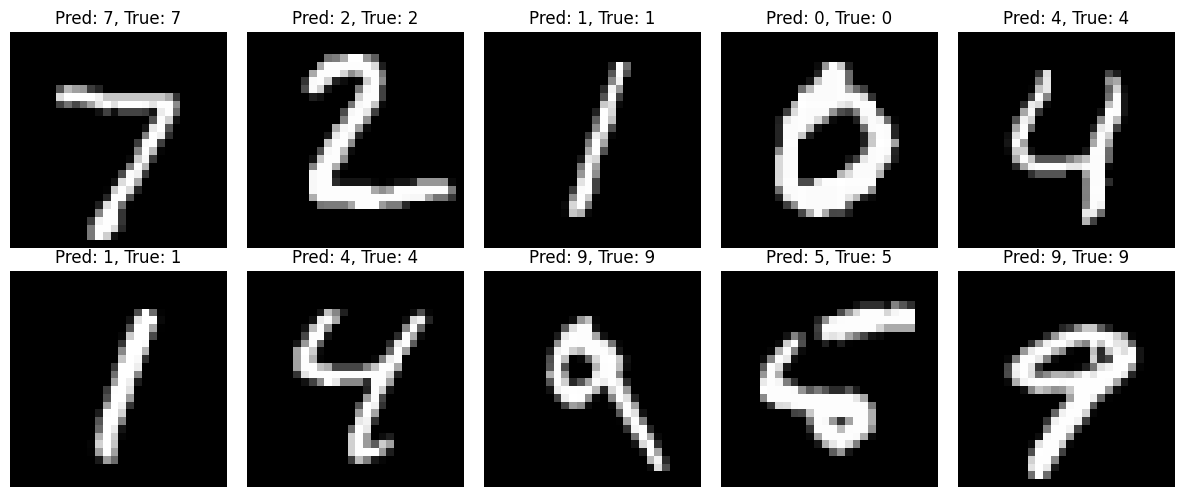

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {y_test_pred_labels[i]}, True: {y_test_true_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()